# Бэггинг и случайный лес

<h3>План занятия</h3>

* **Связь с прошлым занятием** — что такое bias и variance (вспоминаем)
* **Bootstrap** — как из одной выборки сделать много
* **Bagging**
  - формула усреднения и почему оно снижает разброс
  - когда бэггинг помогает, а когда нет (деревья vs логистическая регрессия)
* **Random Forest**
  - декорреляция деревьев через `max_features`
  - применение на реальной задаче (отток клиентов)
  - out-of-bag оценка и важность признаков
* **Выводы**

> 📎 Это занятие продолжает ноутбук **`bias_variance_demo.ipynb`**. Там мы разобрали,
> из чего состоит ошибка модели. Здесь — как с помощью **ансамблей** (композиций
> из многих моделей) бить по одной из её составляющих.


In [ ]:
import warnings
warnings.simplefilter("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_gaussian_quantiles, make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (BaggingClassifier, BaggingRegressor,
                              RandomForestClassifier)
from sklearn.model_selection import (cross_val_score, StratifiedKFold,
                                     train_test_split, GridSearchCV)
from sklearn.metrics import accuracy_score

from ipywidgets import interact, IntSlider, FloatSlider, Dropdown

plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

Сгенерируем два игрушечных набора данных, на которых будем всё показывать.

In [ ]:
def make_circle_data(n=400, seed=0):
    """Inner blob (class 0) wrapped by an outer ring (class 1).

    A single straight line cannot separate these two classes.
    """
    X, y = make_gaussian_quantiles(n_samples=n, n_features=2,
                                   n_classes=2, random_state=seed)
    return X, y


def make_wave_data(n=100, noise=0.7, seed=0):
    """1D regression target: a smooth cosine plus Gaussian noise."""
    rng = np.random.RandomState(seed)
    x = np.linspace(-2 * np.pi, 2 * np.pi, n)
    y = 2 * np.cos(x) + 2 + rng.randn(n) * noise
    return x.reshape(-1, 1), y

In [ ]:
#@title Вспомогательные функции для графиков (можно не читать) { display-mode: "form" }
def plot_decision_boundary(model, X, y, ax, title=""):
    """Draw filled decision regions of a fitted classifier over a 2D grid."""
    h = 0.05
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.7)
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=1.8)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu_r', edgecolor='k', s=25)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

## Вспомним: из чего состоит ошибка модели

В прошлом ноутбуке мы разложили ожидаемую ошибку модели на три части:

$$\underbrace{\mathbb{E}\big[(y - \hat a(x))^2\big]}_{\text{полная ошибка}}
 = \underbrace{\text{bias}^2}_{\text{смещение}}
 + \underbrace{\text{variance}}_{\text{разброс}}
 + \underbrace{\sigma^2}_{\text{шум}}$$

- **Смещение (bias)** — насколько модель «в среднем» промахивается мимо истинной зависимости. Высокий bias = модель слишком простая (недообучение).
- **Разброс (variance)** — насколько сильно модель «дёргается» при смене обучающей выборки. Высокий variance = модель слишком сложная (переобучение).
- **Шум** $\sigma^2$ — неустранимая случайность в данных.

**Главная мысль занятия:** бэггинг — это инструмент против **разброса (variance)**.
Он почти не трогает смещение. Поэтому его применяют к моделям, у которых variance
большой, а bias маленький — например, к **глубоким деревьям**.


## Bootstrap

Чтобы построить много разных моделей, нужно много разных выборок. Но выборка
у нас одна. **Bootstrap** — это приём «сделать много выборок из одной»:

> Из выборки размера $\ell$ берём $\ell$ объектов **случайно и с возвращением**
> (один и тот же объект может попасть несколько раз, а какой-то — ни разу).

Так из одного датасета получается сколько угодно похожих, но не одинаковых
выборок. На каждой обучим свою модель.

Покрутите ползунки: серым отмечены объекты, **не попавшие** в бутстрэп-выборку
(их называют *out-of-bag*, OOB), числа над точками — сколько раз объект вытянут.


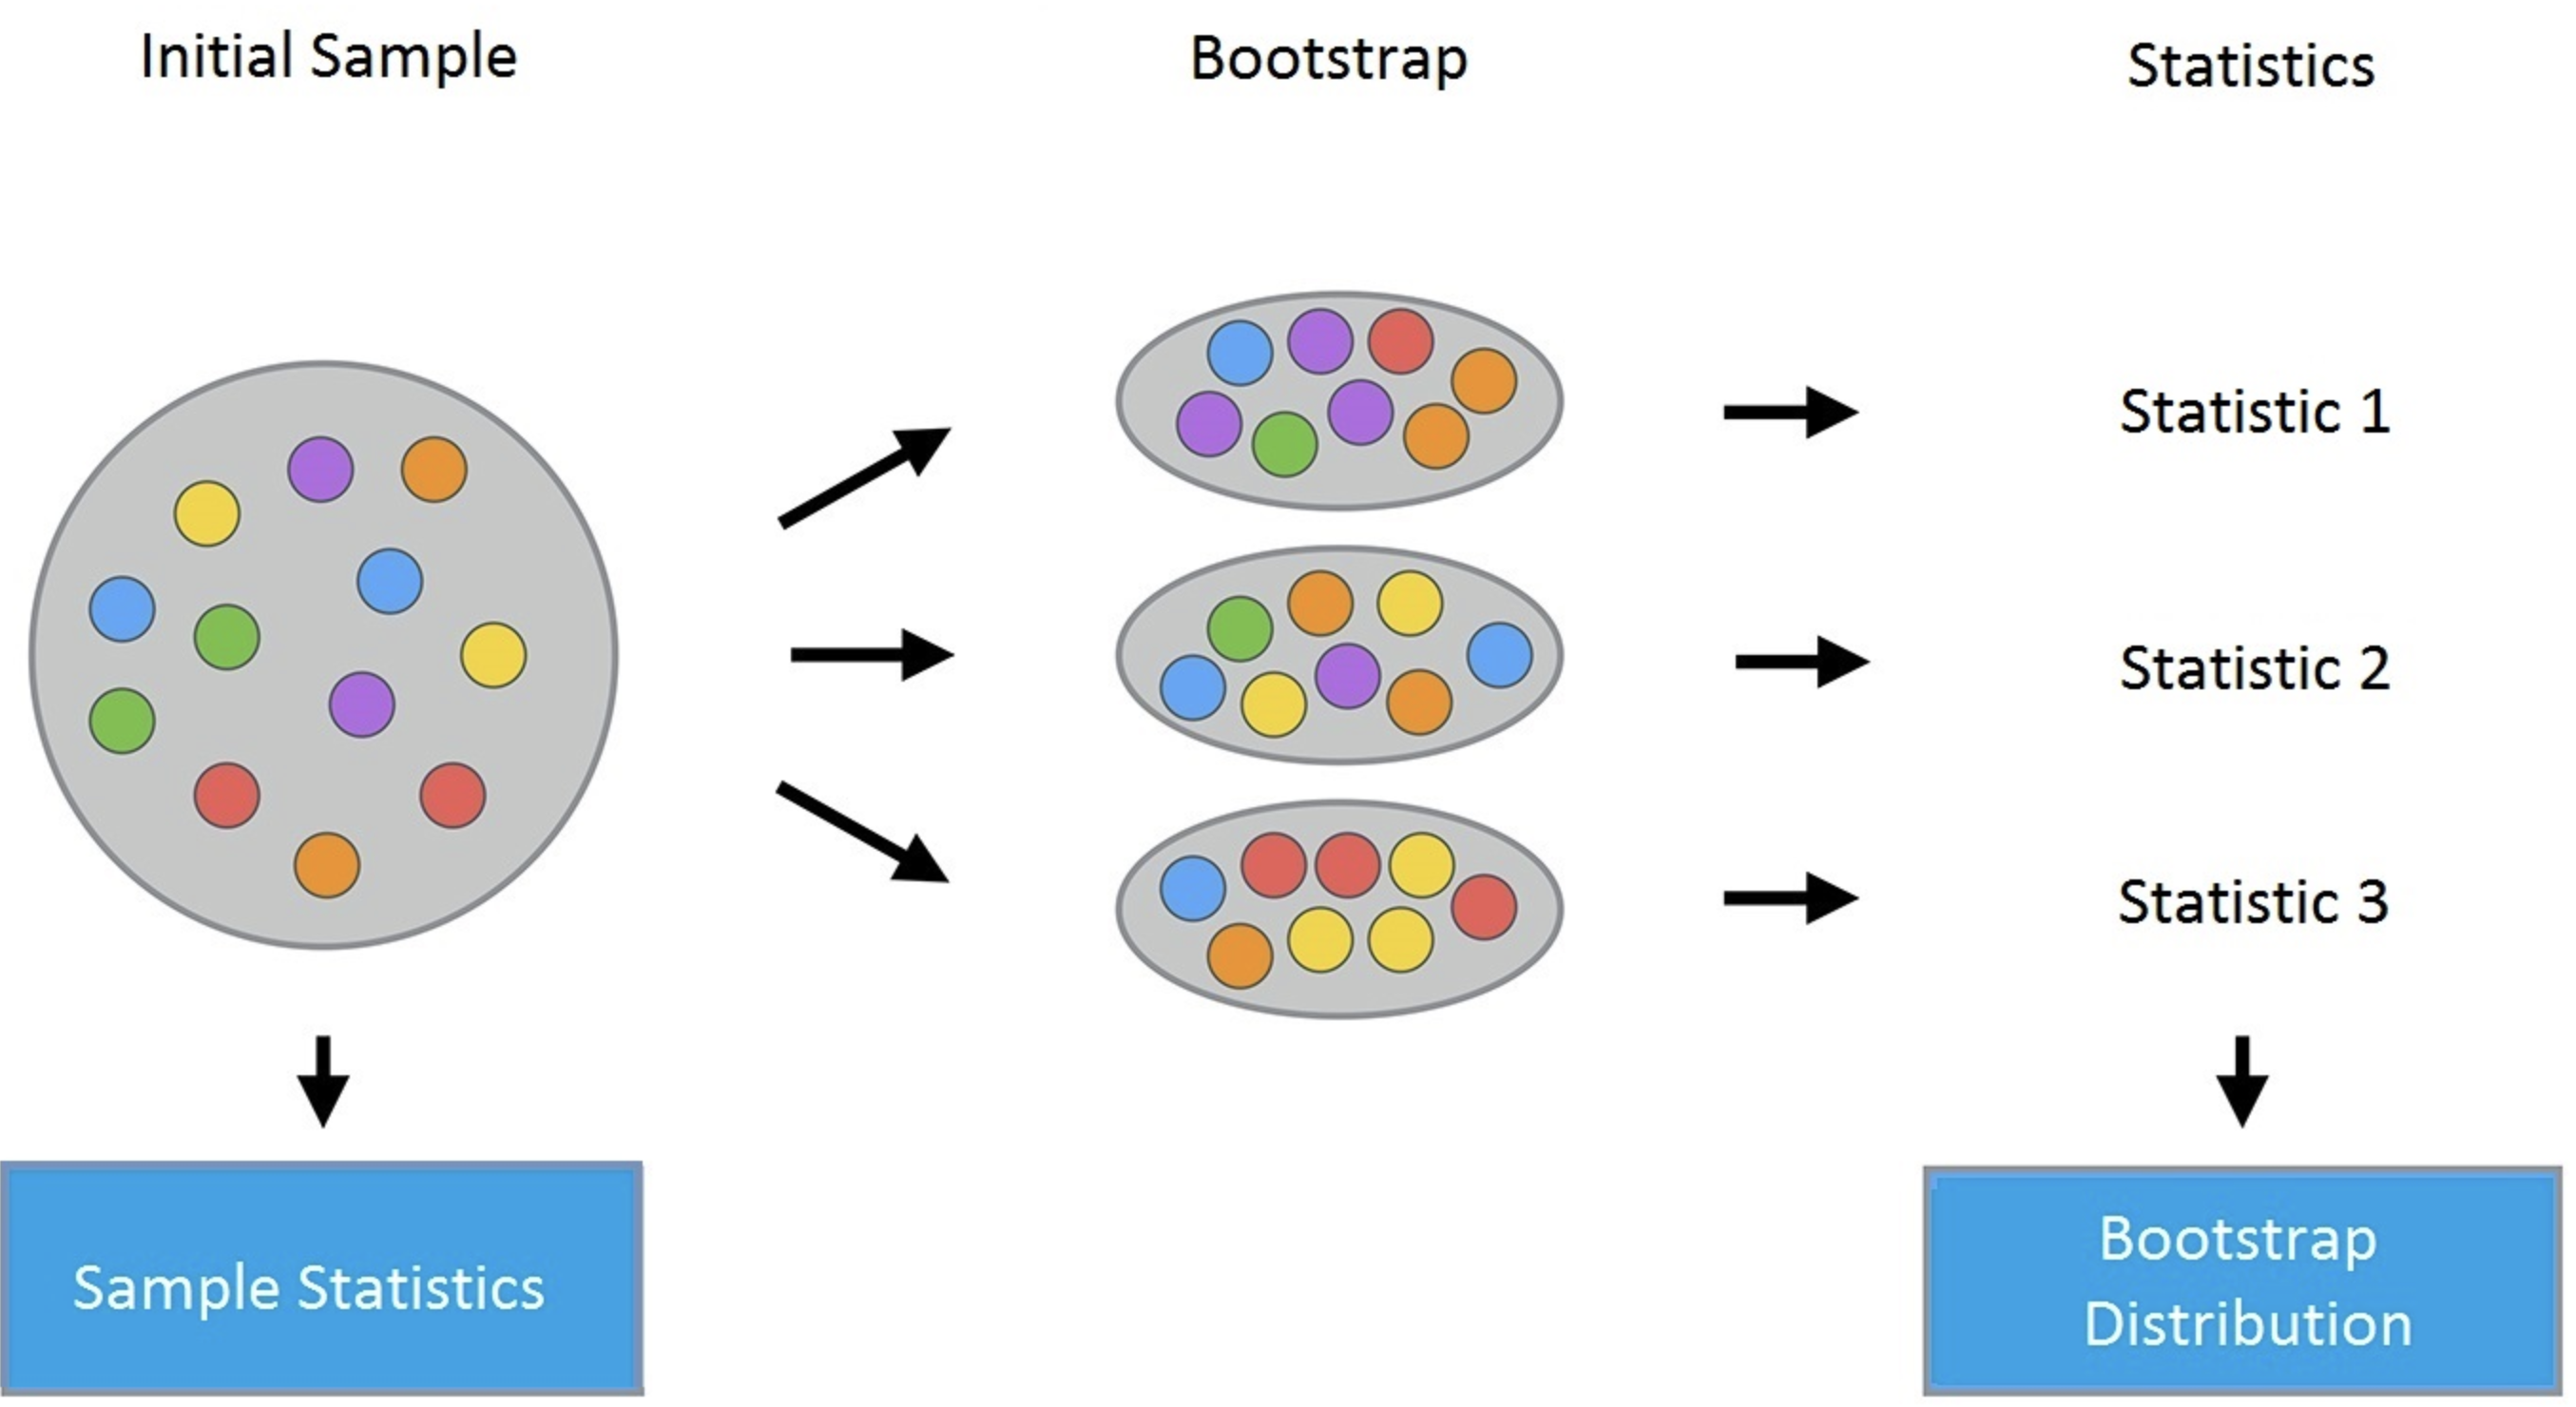

In [ ]:
#@title 🎛️ Бутстрэп и out-of-bag объекты { display-mode: "form" }
def bootstrap_demo(n=20, seed=0):
    """Draw one bootstrap sample and highlight the out-of-bag objects."""
    rng = np.random.RandomState(seed)
    idx = rng.choice(n, n, replace=True)
    counts = np.bincount(idx, minlength=n)
    oob = counts == 0
    frac_in = (~oob).mean()
    fig, ax = plt.subplots(figsize=(11, 2.4))
    ax.scatter(np.arange(n), np.zeros(n), s=160,
               c=['lightgray' if o else 'steelblue' for o in oob],
               edgecolor='k', zorder=2)
    for i in range(n):
        ax.text(i, 0.012, str(counts[i]), ha='center', fontsize=9)
    ax.set_title(f"В бутстрэп попало {frac_in*100:.0f}% объектов;  "
                 f"out-of-bag (серые) — {oob.mean()*100:.0f}%   (теория ≈ 37%)")
    ax.set_ylim(-0.05, 0.05)
    ax.set_yticks([]); ax.set_xticks([])
    plt.show()

interact(bootstrap_demo,
         n=IntSlider(value=20, min=5, max=200, step=5, description="Размер выборки"),
         seed=IntSlider(value=0, min=0, max=20, step=1, description="seed"));

**Почему примерно 37%?** Вероятность, что конкретный объект ни разу не выбран
за $\ell$ попыток:

$$\left(1 - \tfrac{1}{\ell}\right)^{\ell} \xrightarrow{\ell \to \infty} \tfrac{1}{e} \approx 0.37$$

То есть в каждую бутстрэп-выборку попадает ≈ 63% уникальных объектов, а ≈ 37%
остаются «за бортом». К этим 37% мы вернёмся в разделе про **out-of-bag оценку**.


## Bagging (Bootstrap AGGregating)

Алгоритм предельно прост:

1. Сделать $M$ бутстрэп-выборок.
2. На каждой обучить свою модель $a_i(x)$.
3. Усреднить ответы (для регрессии) или проголосовать (для классификации):

$$a_{\text{bag}}(x) = \frac{1}{M}\sum_{i=1}^{M} a_i(x)$$

**Почему это снижает разброс?** Пусть у каждой модели разброс предсказания равен
$v$, а попарная корреляция предсказаний — $\rho$. Тогда разброс усреднённой модели:

$$\mathrm{Var}\big(a_{\text{bag}}\big) = \rho\, v + \frac{1 - \rho}{M}\, v$$

- Второе слагаемое $\frac{1-\rho}{M}v$ **гасится усреднением**: чем больше $M$, тем оно меньше.
- Первое слагаемое $\rho v$ усреднением **не убрать** — это «общая» ошибка, одинаковая у всех моделей.

Запустите демо: синие линии — предсказания отдельных деревьев на бутстрэп-выборках,
красная — их среднее. Следите за числом `Var` (разброс ансамбля) при росте $M$.


In [ ]:
#@title 🎛️ Усреднение гасит разброс (1D-регрессия) { display-mode: "form" }
x_grid = np.linspace(-2 * np.pi, 2 * np.pi, 300).reshape(-1, 1)

def averaging_demo(M=1):
    """Estimate the variance of the bagged predictor over repeated datasets,
    and visualize the individual trees vs their average for one dataset."""
    R = 12  # independent datasets used to estimate the estimator's variance
    grid_preds = []
    last_bag, last_xy = None, None
    for r in range(R):
        xr, yr = make_wave_data(n=100, noise=0.7, seed=100 + r)
        bag = BaggingRegressor(DecisionTreeRegressor(),
                               n_estimators=int(M), random_state=0)
        bag.fit(xr, yr)
        grid_preds.append(bag.predict(x_grid))
        last_bag, last_xy = bag, (xr, yr)
    var = np.array(grid_preds).var(axis=0).mean()

    xr, yr = last_xy
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(xr, yr, color='black', s=18, label='данные')
    for est in last_bag.estimators_:
        ax.plot(x_grid, est.predict(x_grid), color='steelblue', alpha=0.15)
    ax.plot(x_grid, last_bag.predict(x_grid), color='red', linewidth=2.5,
            label='среднее (бэггинг)')
    ax.set_title(f"M = {int(M)} деревьев     разброс ансамбля Var = {var:.4f}")
    ax.legend(loc='upper right')
    plt.show()

interact(averaging_demo,
         M=IntSlider(value=1, min=1, max=80, step=1, description="Деревьев M"));

## Когда бэггинг помогает, а когда — нет

Из формулы $\mathrm{Var}(a_{\text{bag}}) = \rho v + \frac{1-\rho}{M}v$ следует
важный вывод: **усреднять стоит только модели с большим разбросом $v$.**

- **Глубокое дерево** — низкий bias, **высокий $v$**: на разных бутстрэп-выборках
  оно строит заметно разные границы. Усреднение режет разброс сильно → большой выигрыш.
- **Логистическая регрессия** — стабильная модель: **низкий $v$**, и на бутстрэпе
  она почти не меняется ($\rho \approx 1$). Подставим: $\rho v + \frac{1-\rho}{M}v \approx v$
  — усреднять нечего, выигрыша почти нет.

Проверим на наборе «**круг в круге**»: внутри — один класс, вокруг — другой.
Одной прямой их не разделить. Переключайте базовую модель и число $M$:


In [ ]:
#@title 🎛️ Что «выпиливает» ансамбль на «круге в круге» { display-mode: "form" }
X_circ, y_circ = make_circle_data(n=400, seed=0)

def boundary_demo(base="логрег", M=1):
    """Fit a bagging ensemble of the chosen base model and show its boundary."""
    est = LogisticRegression() if base == "логрег" else DecisionTreeClassifier()
    model = BaggingClassifier(est, n_estimators=int(M), random_state=0)
    model.fit(X_circ, y_circ)
    acc = accuracy_score(y_circ, model.predict(X_circ))
    fig, ax = plt.subplots(figsize=(6, 6))
    plot_decision_boundary(model, X_circ, y_circ, ax,
                           title=f"База: {base}    M = {int(M)}    accuracy = {acc:.2f}")
    plt.show()

interact(boundary_demo,
         base=Dropdown(options=["логрег", "дерево"], value="логрег", description="База"),
         M=IntSlider(value=1, min=1, max=50, step=1, description="Деревьев M"));

**Что видно:**

- **Логрег, любое $M$** → граница так и остаётся **прямой**. Бэггинг усредняет
  десяток почти одинаковых прямых и получает снова прямую. Круг не отделён,
  accuracy около 0.5 — бэггинг логрегу **не помог**.
- **Дерево, $M=1$** → рваная ступенчатая граница (это и есть высокий разброс).
- **Дерево, $M$ большое** → рваные края отдельных деревьев гасят друг друга,
  граница становится **гладким кругом**, accuracy высокая.

Это и есть главный урок: **бэггинг — машина против variance.** Он помогает
нестабильным моделям (глубокие деревья) и почти бесполезен для стабильных
(логрег, линейные модели). Чтобы сделать линейную модель гибкой, нужен другой
механизм — снижение bias (это уже про бустинг, его разберём отдельно).


## Random Forest

Бэггинг упирается в «пол» $\rho v$: усреднением мы убираем только второе слагаемое,
а первое — $\rho v$ — остаётся. Чтобы опустить и его, надо **уменьшить корреляцию
$\rho$** между деревьями, то есть сделать их менее похожими.

**Идея случайного леса:** при построении *каждого узла* дерево выбирает разбиение
не по всем признакам, а по случайному подмножеству из `max_features` штук. Тогда
деревья «смотрят» на разные признаки → решают по-разному → корреляция $\rho$ падает.

$$a(x) = \frac{1}{N}\sum_{i=1}^{N} b_i(x), \qquad
\text{где } b_i \text{ — дерево на бутстрэпе + случайные признаки в узлах}$$

Покрутите `max_features`: чем оно меньше, тем сильнее декоррелированы деревья
(меньше $\rho$), но и каждое дерево по отдельности слабее. Где-то посередине —
оптимум.


In [ ]:
#@title 🎛️ Чем меньше max_features, тем слабее корреляция деревьев { display-mode: "form" }
X_clf, y_clf = make_classification(n_samples=600, n_features=10, n_informative=6,
                                   n_redundant=2, random_state=0)
Xtr_f, Xte_f, ytr_f, yte_f = train_test_split(X_clf, y_clf, test_size=0.3,
                                              random_state=0)

def forest_corr_demo(max_features=10):
    """Fit a forest and report the mean pairwise correlation of tree outputs."""
    rf = RandomForestClassifier(n_estimators=100, max_features=int(max_features),
                                random_state=0, n_jobs=-1)
    rf.fit(Xtr_f, ytr_f)
    # probability of class 1 predicted by each individual tree on the test set
    P = np.array([t.predict_proba(Xte_f)[:, 1] for t in rf.estimators_])
    C = np.corrcoef(P)
    rho = C[np.triu_indices_from(C, k=1)].mean()
    acc = accuracy_score(yte_f, rf.predict(Xte_f))
    print(f"max_features = {int(max_features)}")
    print(f"средняя попарная корреляция деревьев  ρ ≈ {rho:.3f}")
    print(f"точность леса на тесте               = {acc:.3f}")

interact(forest_corr_demo,
         max_features=IntSlider(value=10, min=1, max=10, step=1,
                                description="max_features"));

Число признаков `max_features` для каждого узла обычно берут равным:
- $\sqrt{n}$ — для классификации,
- $n/3$ — для регрессии,

где $n$ — общее число признаков. Это разумные значения по умолчанию, но их
полезно подбирать (см. ниже).


## Random Forest на реальной задаче: отток клиентов

Теперь применим лес к настоящей задаче — предсказать, **уйдёт ли клиент**
телеком-оператора (`Churn`).

**Кратко о датасете Telecom Churn:**
- ~3000 клиентов, целевая переменная `Churn` (ушёл / остался);
- числовые признаки: длительность звонков днём/вечером/ночью, число звонков в
  поддержку, длительность обслуживания и т.д.;
- категориальные: штат, наличие международного тарифа и голосовой почты.

Для простоты возьмём только числовые признаки.


In [ ]:
url = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/master/data/telecom_churn.csv"
df = pd.read_csv(url)
df.head()

In [ ]:
# keep numeric features only, target -> int labels
num_cols = [c for c in df.columns if df[c].dtype in ("int64", "float64")]
X = df[num_cols].copy()
y = df["Churn"].astype("int8").values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Сначала — случайный лес «из коробки», без настройки:

In [ ]:
rfc = RandomForestClassifier(random_state=42, n_jobs=-1)
acc = cross_val_score(rfc, X, y, cv=skf, scoring='accuracy').mean()
print("CV accuracy «из коробки»: {:.2f}%".format(acc * 100))

### Кривые валидации

Посмотрим, как качество на train и на кросс-валидации зависит от основных
гиперпараметров. Это тот же диагностический приём, что и в ноутбуке про
bias–variance: расхождение train и cv — признак переобучения (высокого variance).


In [ ]:
#@title Вспомогательные функции для кривых валидации { display-mode: "form" }
def rf_validation_curve(build_model, grid):
    """Train/CV accuracy curve. build_model(value) must return an estimator."""
    tr_curve, cv_curve = [], []
    for v in grid:
        model = build_model(v)
        tr, te = [], []
        for a, b in skf.split(X, y):
            model.fit(X.iloc[a], y[a])
            tr.append(model.score(X.iloc[a], y[a]))
            te.append(model.score(X.iloc[b], y[b]))
        tr_curve.append(np.mean(tr))
        cv_curve.append(np.mean(te))
    return np.array(tr_curve), np.array(cv_curve)


def plot_curve(grid, tr, cv, xlabel):
    """Plot train vs cross-validation accuracy against one hyperparameter."""
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(grid, tr, color='blue', marker='o', label='train')
    ax.plot(grid, cv, color='red', marker='o', label='cv')
    ax.legend(loc='best')
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Accuracy")
    best = grid[int(np.argmax(cv))]
    ax.set_title(f"Лучшее cv = {cv.max()*100:.2f}% при {xlabel} = {best}")

**Число деревьев `n_estimators`:**

In [ ]:
grid = [5, 10, 20, 50, 100, 200]
tr, cv = rf_validation_curve(
    lambda n: RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1),
    grid)
plot_curve(grid, tr, cv, "n_estimators")

**Глубина деревьев `max_depth`:**

In [ ]:
grid = [3, 5, 7, 9, 11, 13, 15, 20]
tr, cv = rf_validation_curve(
    lambda d: RandomForestClassifier(n_estimators=100, max_depth=d,
                                     random_state=42, n_jobs=-1),
    grid)
plot_curve(grid, tr, cv, "max_depth")

**Минимальный размер листа `min_samples_leaf`** (тоже регуляризатор):

In [ ]:
grid = [1, 3, 5, 7, 9, 11, 15, 20]
tr, cv = rf_validation_curve(
    lambda m: RandomForestClassifier(n_estimators=100, min_samples_leaf=m,
                                     random_state=42, n_jobs=-1),
    grid)
plot_curve(grid, tr, cv, "min_samples_leaf")

Финальный подбор всех параметров сразу — через `GridSearchCV`:

In [ ]:
parameters = {'max_features': [2, 4, 6],
              'min_samples_leaf': [1, 3, 5],
              'max_depth': [10, 15, 20]}
rfc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
gcv = GridSearchCV(rfc, parameters, n_jobs=-1, cv=skf, scoring='accuracy')
gcv.fit(X, y)
print("Лучшие параметры:", gcv.best_params_)
print("Лучшее cv: {:.2f}%".format(gcv.best_score_ * 100))

### Переобучается ли бэггинг с ростом числа деревьев?

Частый вопрос: если добавлять деревья без конца, не переобучимся ли мы? Проверим
на отложенной выборке.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

for n_estimators in [10, 50, 100, 300, 600]:
    clf = BaggingClassifier(DecisionTreeClassifier(),
                            n_estimators=n_estimators, n_jobs=-1, random_state=42)
    clf.fit(X_train, y_train)
    tr = accuracy_score(y_train, clf.predict(X_train))
    te = accuracy_score(y_test, clf.predict(X_test))
    print(f"n_estimators={n_estimators:4d}   train={tr:.3f}   test={te:.3f}")

**Вывод:** с ростом числа деревьев test-качество выходит на плато и больше
не падает. Лишние деревья не вредят — они лишь точнее усредняют. Поэтому бэггинг
**очень трудно переобучить добавлением деревьев** (переобучение приходит от
сложности *одного* дерева, а не от их количества).


## Out-of-bag (OOB) оценка

Вспомним: в каждую бутстрэп-выборку попадает ≈ 63% объектов, а ≈ 37% остаются
**out-of-bag** (не участвовали в обучении данного дерева).

**Идея OOB-оценки:** для каждого объекта соберём голоса только тех деревьев,
которые его *не видели* при обучении, и сравним с истинной меткой. Получается
честная оценка качества — **бесплатно, без отдельной кросс-валидации**: роль
теста для каждого дерева играют его собственные ~37% невидимых объектов.

Сравним OOB-оценку с качеством на настоящей отложенной выборке — они близки:


In [ ]:
rfc = RandomForestClassifier(n_estimators=500, oob_score=True,
                             random_state=42, n_jobs=-1)
rfc.fit(X_train, y_train)
print("OOB score:        {:.3f}".format(rfc.oob_score_))
print("Test accuracy:    {:.3f}".format(accuracy_score(y_test, rfc.predict(X_test))))

OOB-оценка ≈ тестовому качеству. Это удобно: на больших данных можно не
тратить часть выборки на отдельный тест, а ориентироваться на `oob_score_`.


## Важность признаков (feature importance)

Лес умеет оценивать, **какие признаки важнее**. Самый частый способ: для каждого
признака суммируют (по всем узлам всех деревьев) уменьшение критерия информативности,
которое он дал, взвешенное по числу попавших в узел объектов, и усредняют по деревьям.

> ⚠️ Этот способ (impurity-based) завышает важность признаков с многими уникальными
> значениями. Более честная альтернатива — **permutation importance**: случайно
> перемешать значения признака на тесте и посмотреть, насколько просядет качество.


In [ ]:
forest = RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1)
forest.fit(X, y)
importances = pd.Series(forest.feature_importances_,
                        index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot.barh(color='grey', edgecolor='black', ax=ax)
ax.set_title("Важность признаков (RandomForest)")
ax.set_xlabel("важность")
plt.tight_layout()

## Выводы

**Bagging:**
- усредняет много моделей, обученных на бутстрэп-выборках;
- **снижает разброс (variance)**, почти не меняя смещение (bias);
- формула: $\mathrm{Var}(a_{\text{bag}}) = \rho v + \frac{1-\rho}{M}v$;
- помогает **нестабильным** моделям (глубокие деревья) и **не помогает** стабильным
  (логрег, линейные) — это мы видели на «круге в круге»;
- очень трудно переобучить добавлением моделей.

**Random Forest = bagging над деревьями + случайные признаки в узлах:**
- случайный выбор `max_features` **декоррелирует** деревья (уменьшает $\rho$) →
  опускает «пол» разброса ниже, чем у обычного бэггинга;
- деревья делают **глубокими** (низкий bias), а разброс гасит лес;
- хорошо работает «из коробки», не чувствителен к масштабу признаков и выбросам;
- даёт бесплатную **OOB-оценку** и **важность признаков**.


## Вопросы и ответы

**1) Какой глубины делать деревья в случайном лесу?**
Разброс гасит сам лес (усреднением), а на смещение он не влияет — значит, смещение
должно быть маленьким уже у отдельных деревьев. Маленький bias = **глубокие деревья**.
Поэтому в RF деревья обычно не обрезают.

**2) Сколько признаков подавать в узел (`max_features`)?**
Чем меньше — тем слабее коррелированы деревья (ниже $\rho$, ниже разброс леса), но
тем слабее каждое дерево по отдельности (выше bias). Оптимум обычно около $\sqrt{n}$
для классификации и $n/3$ для регрессии; точное значение подбирают.

**3) Чем Random Forest отличается от простого бэггинга деревьев?**
Только одним: в RF в каждом узле перебираются не все признаки, а случайное
подмножество. Этого достаточно, чтобы деревья стали разнообразнее и лес обогнал
обычный бэггинг.

**4) Поможет ли бэггинг линейной модели?**
Почти нет: линейная модель стабильна (низкий variance), усреднять нечего. Чтобы
улучшить линейную модель, нужно снижать bias — это делает бустинг, а не бэггинг.
